In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, accuracy_score


# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Data
deliveries_path = '../Dataset/deliveries.csv'
matches_path = '../Dataset/matches.csv'
deliveries = pd.read_csv(deliveries_path)
matches = pd.read_csv(matches_path)

# 1. Total Runs
match_runs = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
match_runs.columns = ['match_id', 'total_score']

# 2. Powerplay
pp = deliveries[deliveries['over'] < 6].groupby('match_id')['total_runs'].sum().reset_index()
pp.columns = ['match_id', 'powerplay_runs']

# 3. Death Overs
death = deliveries[deliveries['over'] >= 15].groupby('match_id')['total_runs'].sum().reset_index()
death.columns = ['match_id', 'death_runs']

# 4. Boundaries
bounds = deliveries[deliveries['batsman_runs'].isin([4, 6])].groupby('match_id')['batsman_runs'].count().reset_index()
bounds.columns = ['match_id', 'boundary_count']

# 5. Wickets Lost
wickets = deliveries[deliveries['is_wicket'] == 1].groupby('match_id').size().reset_index(name='wickets_lost')

# Combine
features = match_runs.merge(pp, on='match_id', how='left').merge(death, on='match_id', how='left').merge(bounds, on='match_id', how='left').merge(wickets, on='match_id', how='left').fillna(0)

matches_sub = matches[['id', 'season', 'city', 'venue']].copy()
matches_sub.columns = ['match_id', 'season', 'city', 'venue']
df = matches_sub.merge(features, on='match_id', how='left')
df['is_high_score'] = (df['total_score'] >= 320).astype(int)
df = df.sort_values('season')
df = df.sort_values('total_score', ascending=False)
print("Dataset shape:", df.shape)
print("\nFeature Statistics:")
print(df[['total_score', 'powerplay_runs', 'death_runs', 'boundary_count', 'wickets_lost']].describe())


Dataset shape: (1095, 10)

Feature Statistics:
       total_score  powerplay_runs   death_runs  boundary_count  wickets_lost
count  1095.000000     1095.000000  1095.000000     1095.000000   1095.000000
mean    317.585388       94.262100    85.738813       39.178995     11.826484
std      59.146981       19.923936    29.795760       10.523453      3.103196
min      56.000000       31.000000     0.000000        5.000000      3.000000
25%     283.000000       81.000000    69.000000       32.000000     10.000000
50%     320.000000       94.000000    88.000000       39.000000     12.000000
75%     353.500000      107.000000   106.000000       46.000000     14.000000
max     549.000000      213.000000   173.000000       81.000000     21.000000


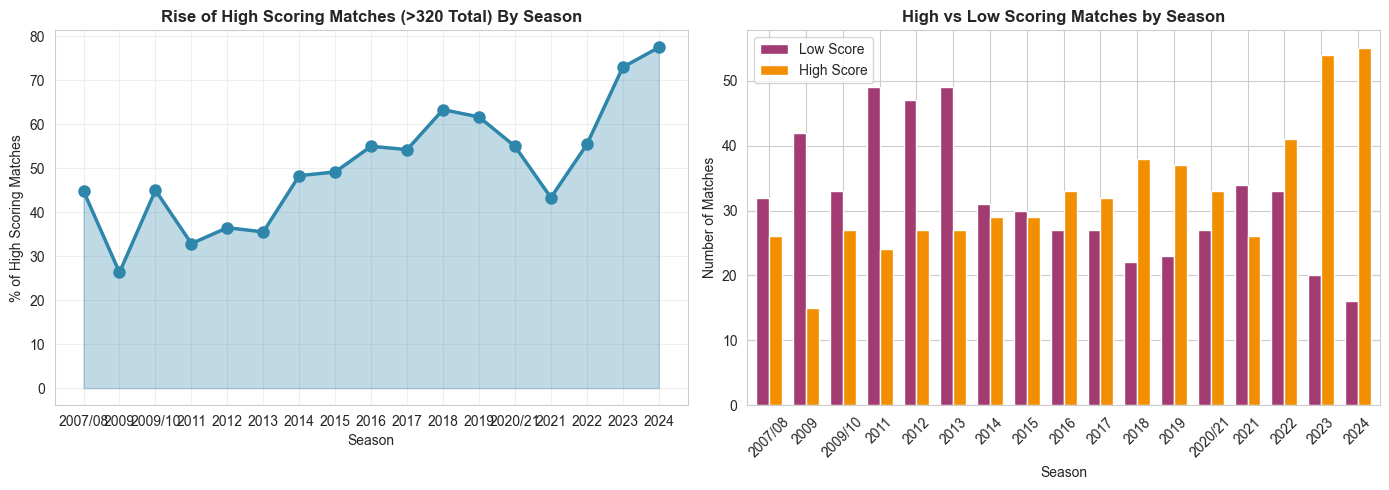

In [59]:
# 1. Rise of High Scoring Matches over the Seasons
season_trend = df.groupby('season')['is_high_score'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot
axes[0].plot(season_trend.index, season_trend.values, marker='o', color='#2E86AB', linewidth=2.5, markersize=8)
axes[0].fill_between(season_trend.index, season_trend.values, alpha=0.3, color='#2E86AB')
axes[0].set_title('Rise of High Scoring Matches (>320 Total) By Season', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('% of High Scoring Matches')
axes[0].grid(True, alpha=0.3)

# Distribution plot
high_score_counts = df.groupby('season')['is_high_score'].value_counts().unstack(fill_value=0)
high_score_counts.plot(kind='bar', ax=axes[1], color=['#A23B72', '#F18F01'], width=0.7)
axes[1].set_title('High vs Low Scoring Matches by Season', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Number of Matches')
axes[1].legend(['Low Score', 'High Score'], loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


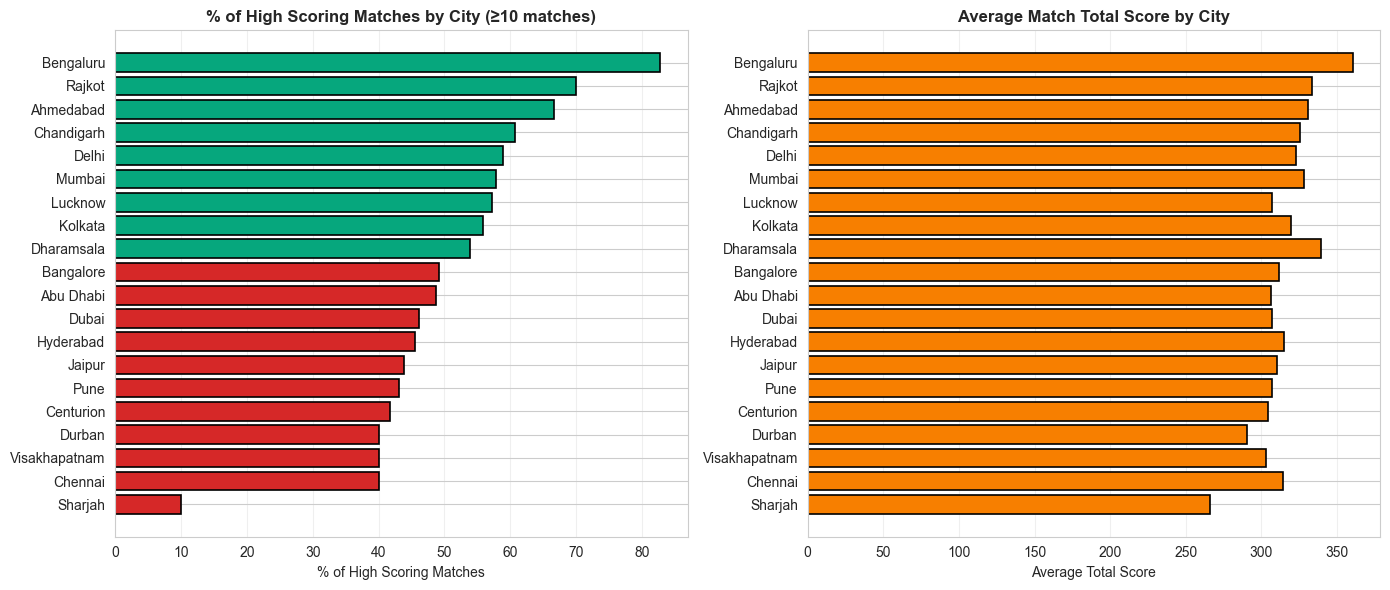

In [47]:
# 2. Pitch Condition (City/Venue) vs High Scores - Enhanced Visualization
city_stats = df.groupby('city')['is_high_score'].mean().sort_values(ascending=False) * 100
city_counts = df['city'].value_counts()
valid_cities = city_counts[city_counts >= 10].index
filtered_city_stats = city_stats[valid_cities].sort_values()
avg_score_by_city = df[df['city'].isin(valid_cities)].groupby('city')['total_score'].mean().loc[filtered_city_stats.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barh plot with dual info
colors = ['#06A77D' if x > 50 else '#D62828' for x in filtered_city_stats.values]
axes[0].barh(filtered_city_stats.index, filtered_city_stats.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('% of High Scoring Matches by City (≥10 matches)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('% of High Scoring Matches')
axes[0].grid(axis='x', alpha=0.3)

# Average score by city
axes[1].barh(avg_score_by_city.index, avg_score_by_city.values, color='#F77F00', edgecolor='black', linewidth=1.2)
axes[1].set_title('Average Match Total Score by City', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Total Score')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


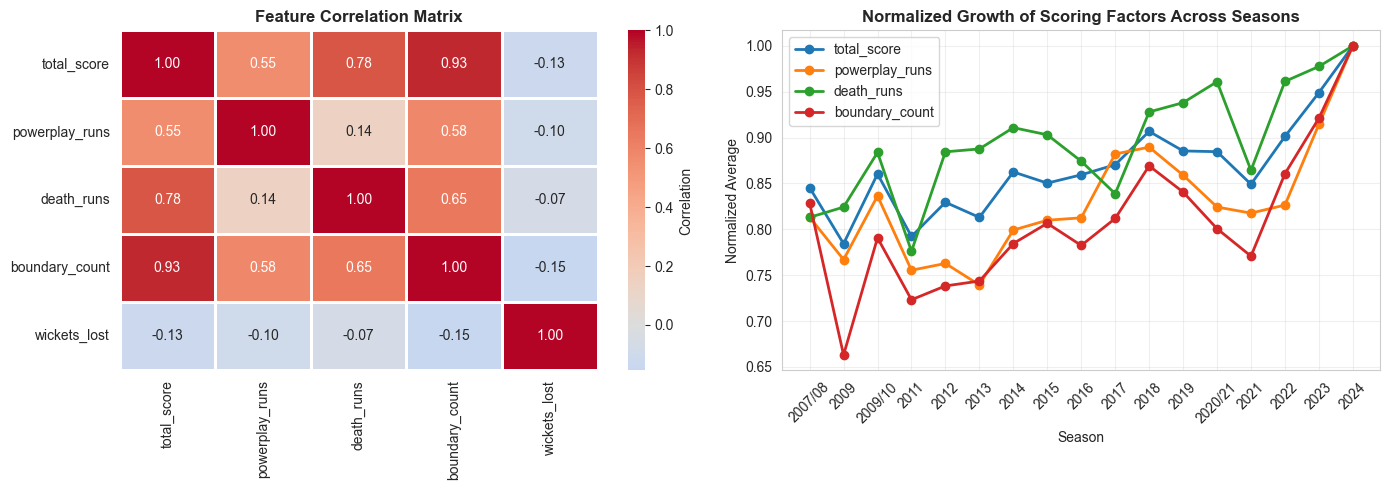

In [ ]:
# 3. Feature Correlation Analysis with Heatmap
correlation_data = df[['total_score', 'powerplay_runs', 'death_runs', 'boundary_count', 'wickets_lost']].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
s       
# Normalized Trend
season_metrics = df.groupby('season')[['total_score', 'powerplay_runs', 'death_runs', 'boundary_count']].mean()
normalized_metrics = season_metrics.div(season_metrics.max())

for col in normalized_metrics.columns:
    axes[1].plot(normalized_metrics.index, normalized_metrics[col], marker='o', label=col, linewidth=2)

axes[1].set_title('Normalized Growth of Scoring Factors Across Seasons', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Normalized Average')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


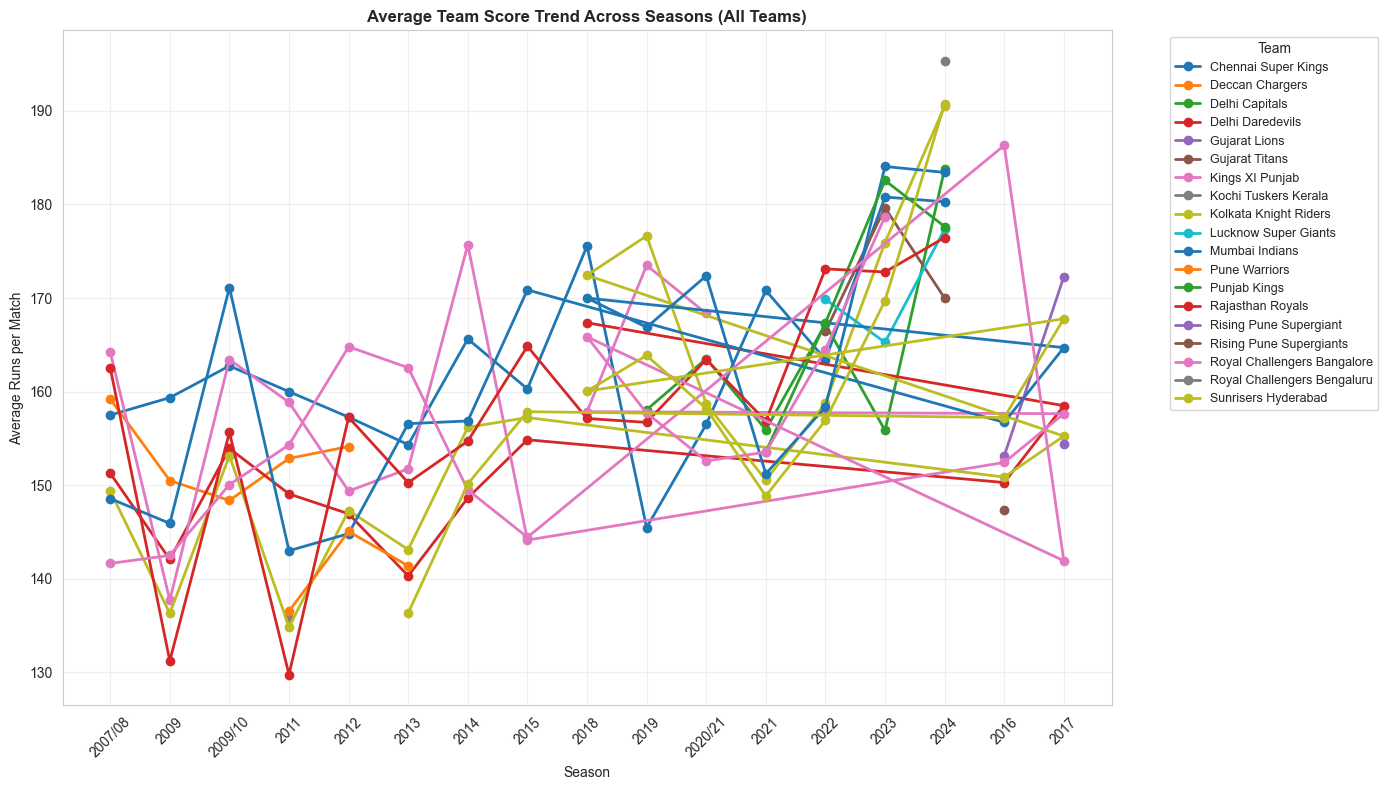

In [49]:
# 4. Team-wise Average Score Trend Over Seasons
team_match_scores = deliveries.groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()
team_match_scores = team_match_scores.merge(matches[['id', 'season']], left_on='match_id', right_on='id', how='inner')
team_season_avg = team_match_scores.groupby(['season', 'batting_team'])['total_runs'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 8))

for team in team_season_avg.columns:
    team_data = team_season_avg[team].dropna()
    ax.plot(team_data.index, team_data.values, marker='o', label=team, linewidth=2, markersize=6)

ax.set_title('Average Team Score Trend Across Seasons (All Teams)', fontsize=12, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Average Runs per Match')
ax.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


LINEAR REGRESSION - Total Score Prediction
RMSE: 15.50
R² Score: 0.9360
Mean Absolute Error: 12.15

Model Coefficients:
  Powerplay Runs: 0.4418
  Death Runs: 0.7245
  Boundary Count: 3.4272
  Wickets Lost: 0.0202
  Intercept: 79.2561


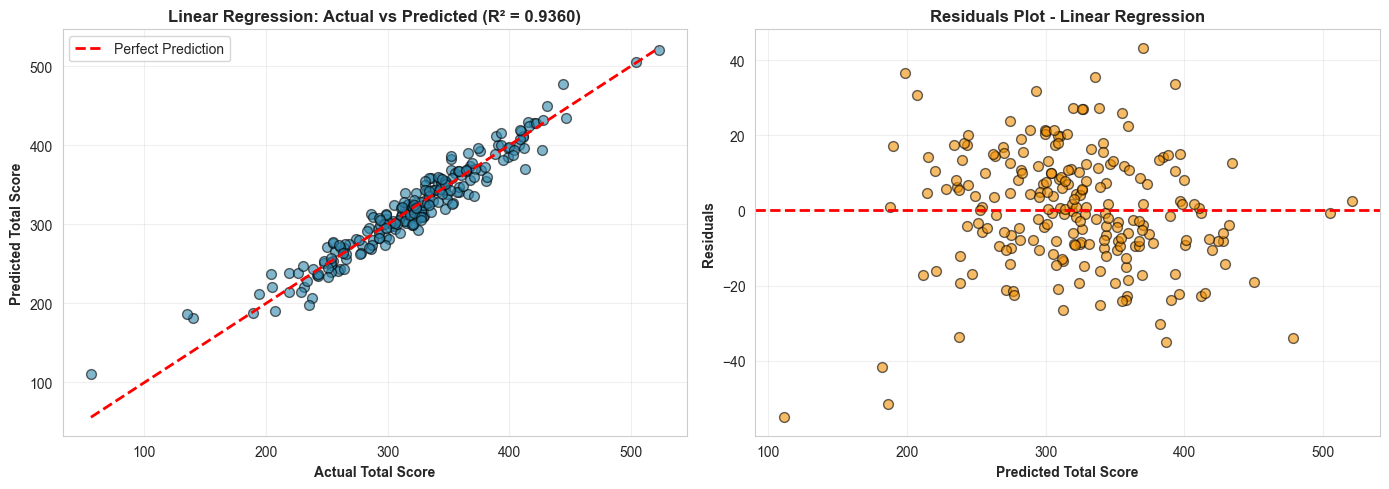

In [50]:
# ML Model 1: Linear Regression to Predict Total Score
# Prepare features and target
X = df[['powerplay_runs', 'death_runs', 'boundary_count', 'wickets_lost']].values
y = df['total_score'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=" * 50)
print("LINEAR REGRESSION - Total Score Prediction")
print("=" * 50)
print(f"RMSE: {rmse_lr:.2f}")
print(f"R² Score: {r2_lr:.4f}")
print(f"Mean Absolute Error: {np.mean(np.abs(y_test - y_pred_lr)):.2f}")
print(f"\nModel Coefficients:")
features_name = ['Powerplay Runs', 'Death Runs', 'Boundary Count', 'Wickets Lost']
for feat, coef in zip(features_name, lr_model.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"  Intercept: {lr_model.intercept_:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter plot
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='#2E86AB', edgecolors='black', s=50)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Total Score', fontweight='bold')
axes[0].set_ylabel('Predicted Total Score', fontweight='bold')
axes[0].set_title(f'Linear Regression: Actual vs Predicted (R² = {r2_lr:.4f})', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.6, color='#F18F01', edgecolors='black', s=50)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Total Score', fontweight='bold')
axes[1].set_ylabel('Residuals', fontweight='bold')
axes[1].set_title('Residuals Plot - Linear Regression', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



RANDOM FOREST - High Score Classification
Accuracy: 0.8904

Confusion Matrix:
[[ 89  10]
 [ 14 106]]

Classification Report:
              precision    recall  f1-score   support

   Low Score       0.86      0.90      0.88        99
  High Score       0.91      0.88      0.90       120

    accuracy                           0.89       219
   macro avg       0.89      0.89      0.89       219
weighted avg       0.89      0.89      0.89       219



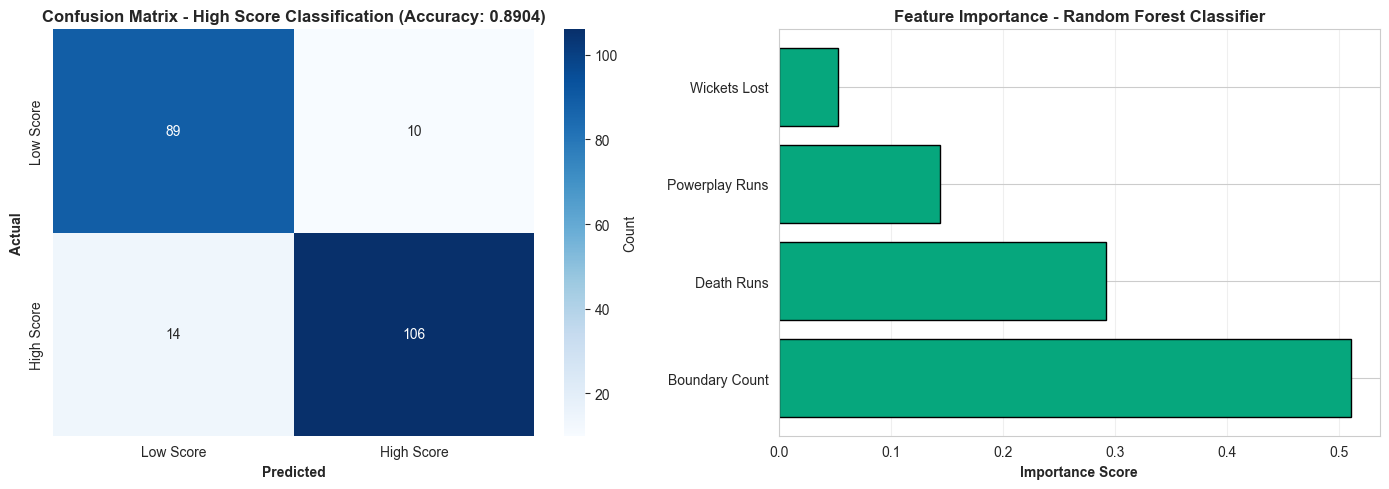

In [ ]:
# ML Model 2: Random Forest for High Score Classification
# Prepare features and target
y_class = df['is_high_score'].values

# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_classifier.fit(X_train_c, y_train_c)

# Predictions
y_pred_class = rf_classifier.predict(X_test_c)
y_pred_prob = rf_classifier.predict_proba(X_test_c)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test_c, y_pred_class)
cm = confusion_matrix(y_test_c, y_pred_class)

print("\n" + "=" * 50)
print("RANDOM FOREST - High Score Classification")
print("=" * 50)
print(f"Accuracy: {accuracy:.4f}")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nClassification Report:\n{classification_report(y_test_c, y_pred_class, target_names=['Low Score', 'High Score'])}")

# Feature Importance
feature_importance = rf_classifier.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Count'},
            xticklabels=['Low Score', 'High Score'], yticklabels=['Low Score', 'High Score'])
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title(f'Confusion Matrix - High Score Classification (Accuracy: {accuracy:.4f})', fontweight='bold')

# Feature Importance
axes[1].barh(range(len(sorted_idx)), feature_importance[sorted_idx], color='#06A77D', edgecolor='black')
axes[1].set_yticks(range(len(sorted_idx)))
axes[1].set_yticklabels([features_name[i] for i in sorted_idx])
axes[1].set_xlabel('Importance Score', fontweight='bold')1
axes[1].set_title('Feature Importance - Random Forest Classifier', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


RANDOM FOREST - Total Score Prediction
RMSE: 16.72
R² Score: 0.9255
Mean Absolute Error: 12.94

Feature Importance (Random Forest):
  Boundary Count: 0.8344
  Death Runs: 0.1199
  Powerplay Runs: 0.0332
  Wickets Lost: 0.0125


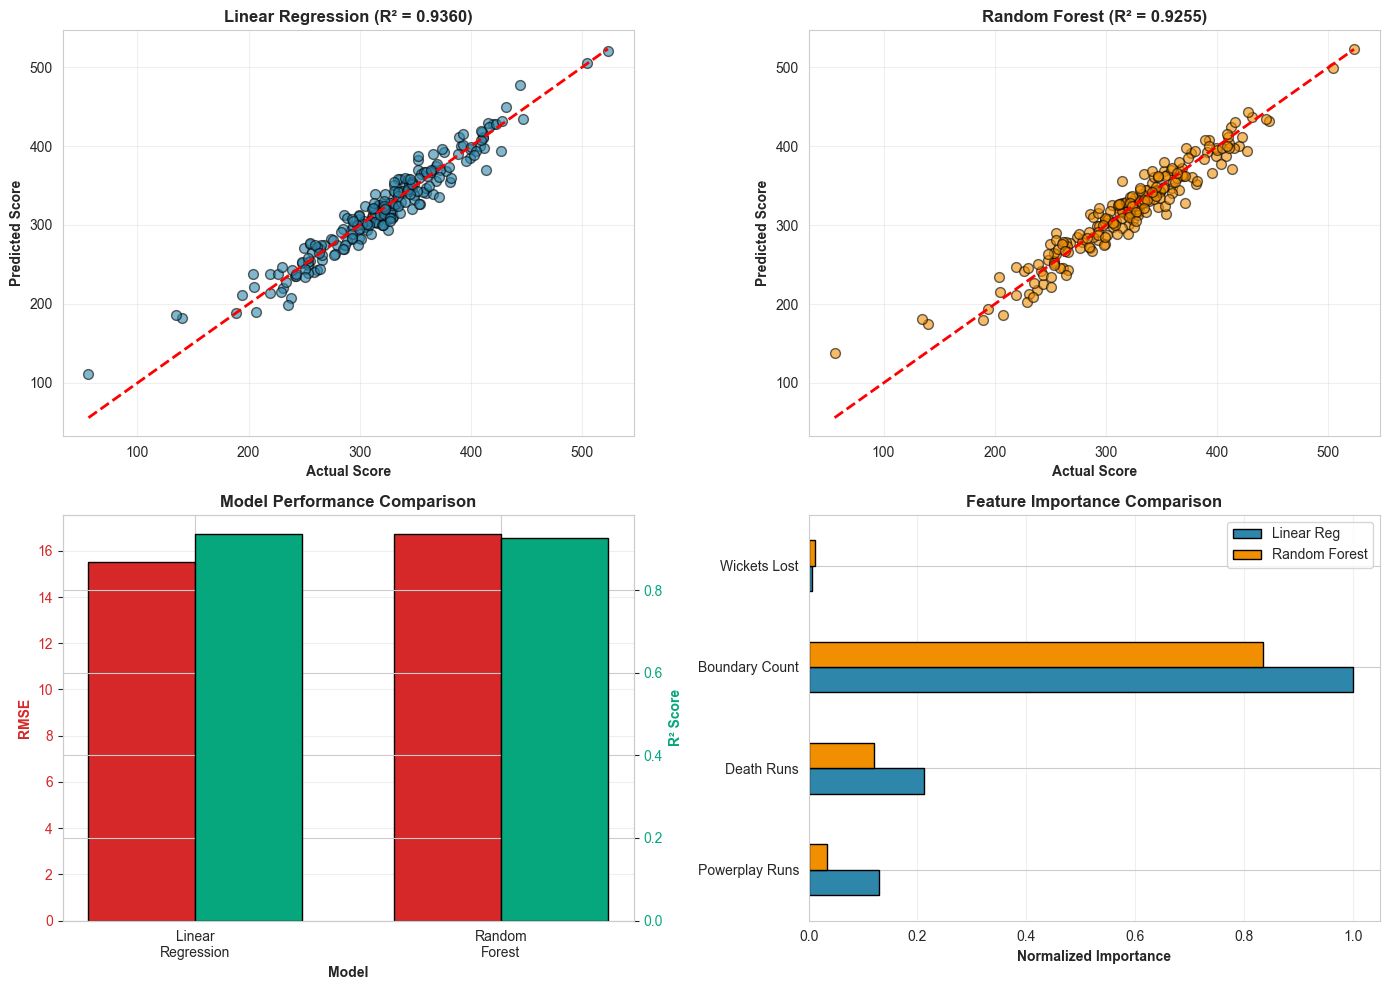

In [60]:
# ML Model 3: Random Forest Regressor for Score Prediction
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
rf_regressor.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_regressor.predict(X_test)

# Evaluation
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n" + "=" * 50)
print("RANDOM FOREST - Total Score Prediction")
print("=" * 50)
print(f"RMSE: {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")
print(f"Mean Absolute Error: {np.mean(np.abs(y_test - y_pred_rf)):.2f}")

# Feature Importance
rf_feature_importance = rf_regressor.feature_importances_
sorted_idx_rf = np.argsort(rf_feature_importance)[::-1]

print(f"\nFeature Importance (Random Forest):")
for feat, imp in zip([features_name[i] for i in sorted_idx_rf], rf_feature_importance[sorted_idx_rf]):
    print(f"  {feat}: {imp:.4f}")

# Model Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Linear Regression - Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_lr, alpha=0.6, color='#2E86AB', edgecolors='black', s=50)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Score', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Score', fontweight='bold')
axes[0, 0].set_title(f'Linear Regression (R² = {r2_lr:.4f})', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Random Forest - Actual vs Predicted
axes[0, 1].scatter(y_test, y_pred_rf, alpha=0.6, color='#F18F01', edgecolors='black', s=50)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Score', fontweight='bold')
axes[0, 1].set_ylabel('Predicted Score', fontweight='bold')
axes[0, 1].set_title(f'Random Forest (R² = {r2_rf:.4f})', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Model Performance Comparison
models = ['Linear\nRegression', 'Random\nForest']
rmse_scores = [rmse_lr, rmse_rf]
r2_scores = [r2_lr, r2_rf]

x_pos = np.arange(len(models))
width = 0.35

ax1 = axes[1, 0]
bars1 = ax1.bar(x_pos - width/2, rmse_scores, width, label='RMSE', color='#D62828', edgecolor='black')
ax2 = ax1.twinx()
bars2 = ax2.bar(x_pos + width/2, r2_scores, width, label='R² Score', color='#06A77D', edgecolor='black')

ax1.set_ylabel('RMSE', fontweight='bold', color='#D62828')
ax2.set_ylabel('R² Score', fontweight='bold', color='#06A77D')
ax1.set_xlabel('Model', fontweight='bold')
ax1.set_title('Model Performance Comparison', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models)
ax1.tick_params(axis='y', labelcolor='#D62828')
ax2.tick_params(axis='y', labelcolor='#06A77D')
ax1.grid(True, alpha=0.3, axis='y')

# 4. Feature Importance Comparison
importance_df = pd.DataFrame({
    'Linear Reg': np.abs(lr_model.coef_) / np.max(np.abs(lr_model.coef_)),
    'Random Forest': rf_feature_importance  
}, index=features_name)

importance_df.plot(kind='barh', ax=axes[1, 1], color=['#2E86AB', '#F18F01'], edgecolor='black')
axes[1, 1].set_xlabel('Normalized Importance', fontweight='bold')
axes[1, 1].set_title('Feature Importance Comparison', fontweight='bold')
axes[1, 1].legend(loc='best')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


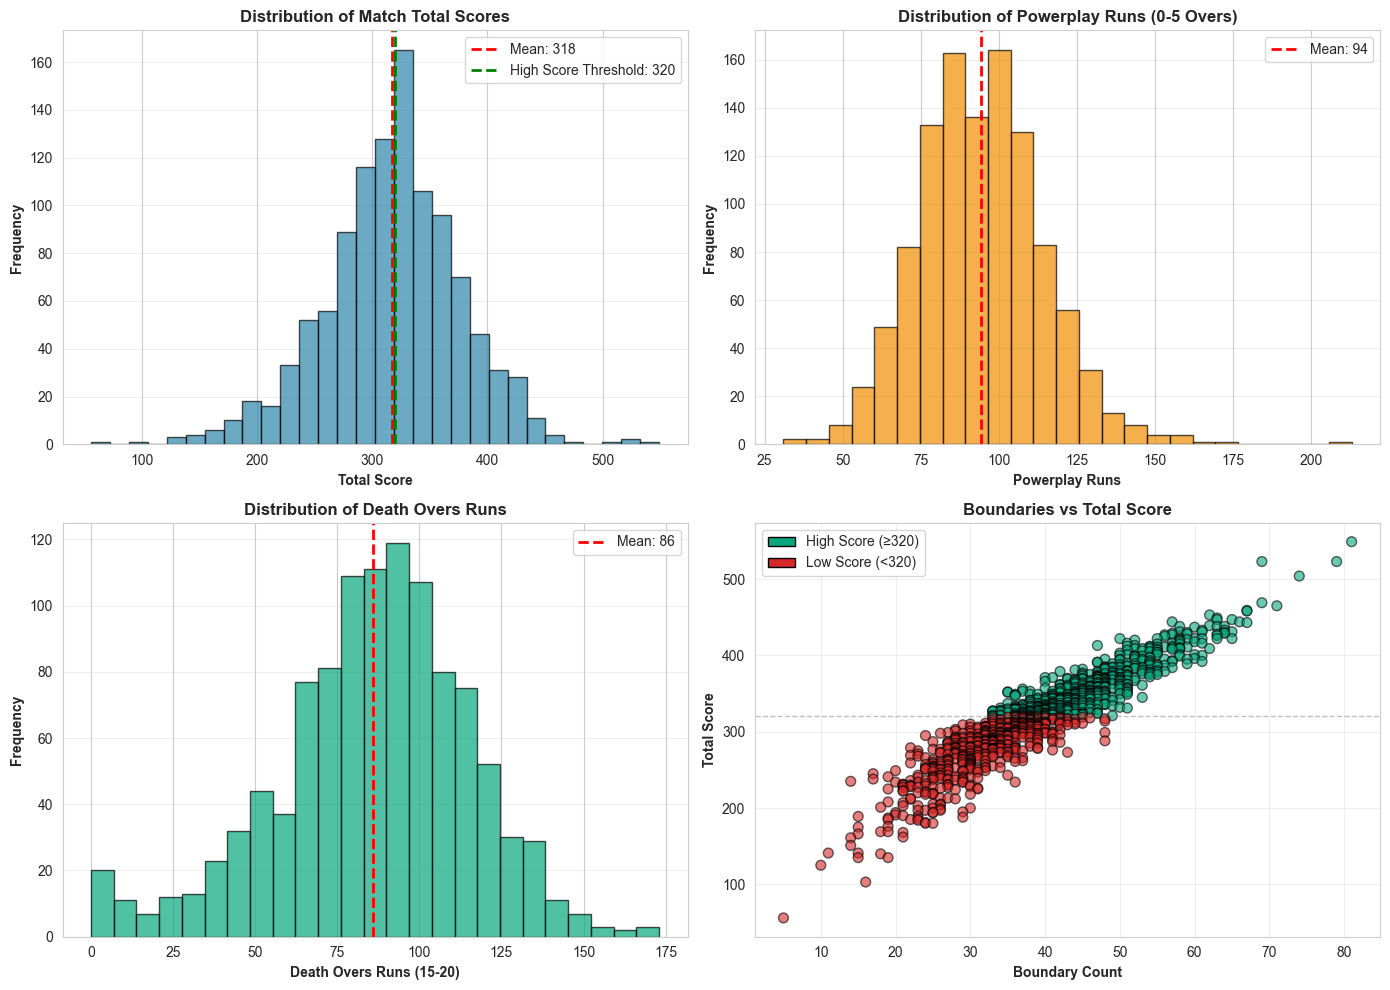


SAMPLE PREDICTIONS

Scenario: Conservative
  Features: Powerplay=30, Death=20, Boundaries=10, Wickets=8
  Linear Regression Prediction: 141 runs
  Random Forest Prediction: 143 runs
  High Score Classification: No (Probability: 0.00%)

Scenario: Moderate
  Features: Powerplay=45, Death=40, Boundaries=20, Wickets=6
  Linear Regression Prediction: 197 runs
  Random Forest Prediction: 189 runs
  High Score Classification: No (Probability: 0.00%)

Scenario: Aggressive
  Features: Powerplay=60, Death=60, Boundaries=30, Wickets=4
  Linear Regression Prediction: 252 runs
  Random Forest Prediction: 249 runs
  High Score Classification: No (Probability: 0.00%)


In [53]:
# 5. Distribution Analysis and Predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of Total Scores
axes[0, 0].hist(df['total_score'], bins=30, color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['total_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["total_score"].mean():.0f}')
axes[0, 0].axvline(320, color='green', linestyle='--', linewidth=2, label='High Score Threshold: 320')
axes[0, 0].set_xlabel('Total Score', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Distribution of Match Total Scores', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Distribution of Powerplay Runs
axes[0, 1].hist(df['powerplay_runs'], bins=25, color='#F18F01', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['powerplay_runs'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["powerplay_runs"].mean():.0f}')
axes[0, 1].set_xlabel('Powerplay Runs', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('Distribution of Powerplay Runs (0-5 Overs)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Distribution of Death Runs
axes[1, 0].hist(df['death_runs'], bins=25, color='#06A77D', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['death_runs'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["death_runs"].mean():.0f}')
axes[1, 0].set_xlabel('Death Overs Runs (15-20)', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Death Overs Runs', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Boundaries vs Total Score (Scatter with color by high score)
colors_scatter = ['#06A77D' if x == 1 else '#D62828' for x in df['is_high_score']]
scatter = axes[1, 1].scatter(df['boundary_count'], df['total_score'], c=colors_scatter, 
                             alpha=0.6, edgecolors='black', s=50)
axes[1, 1].set_xlabel('Boundary Count', fontweight='bold')
axes[1, 1].set_ylabel('Total Score', fontweight='bold')
axes[1, 1].set_title('Boundaries vs Total Score', fontweight='bold')
axes[1, 1].axhline(320, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].grid(True, alpha=0.3)

# Add legend for scatter
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#06A77D', edgecolor='black', label='High Score (≥320)'),
                   Patch(facecolor='#D62828', edgecolor='black', label='Low Score (<320)')]
axes[1, 1].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

# Example Prediction
print("\n" + "=" * 50)
print("SAMPLE PREDICTIONS")
print("=" * 50)

# Create sample scenarios
scenarios = {
    'Conservative': [30, 20, 10, 8],
    'Moderate': [45, 40, 20, 6],
    'Aggressive': [60, 60, 30, 4]
}

for scenario_name, features in scenarios.items():
    features_arr = np.array(features).reshape(1, -1)
    pred_lr = lr_model.predict(features_arr)[0]
    pred_rf = rf_regressor.predict(features_arr)[0]
    pred_class = rf_classifier.predict(features_arr)[0]
    pred_prob = rf_classifier.predict_proba(features_arr)[0]
    
    print(f"\nScenario: {scenario_name}")
    print(f"  Features: Powerplay={features[0]}, Death={features[1]}, Boundaries={features[2]}, Wickets={features[3]}")
    print(f"  Linear Regression Prediction: {pred_lr:.0f} runs")
    print(f"  Random Forest Prediction: {pred_rf:.0f} runs")
    print(f"  High Score Classification: {'Yes' if pred_class == 1 else 'No'} (Probability: {pred_prob[1]:.2%})")


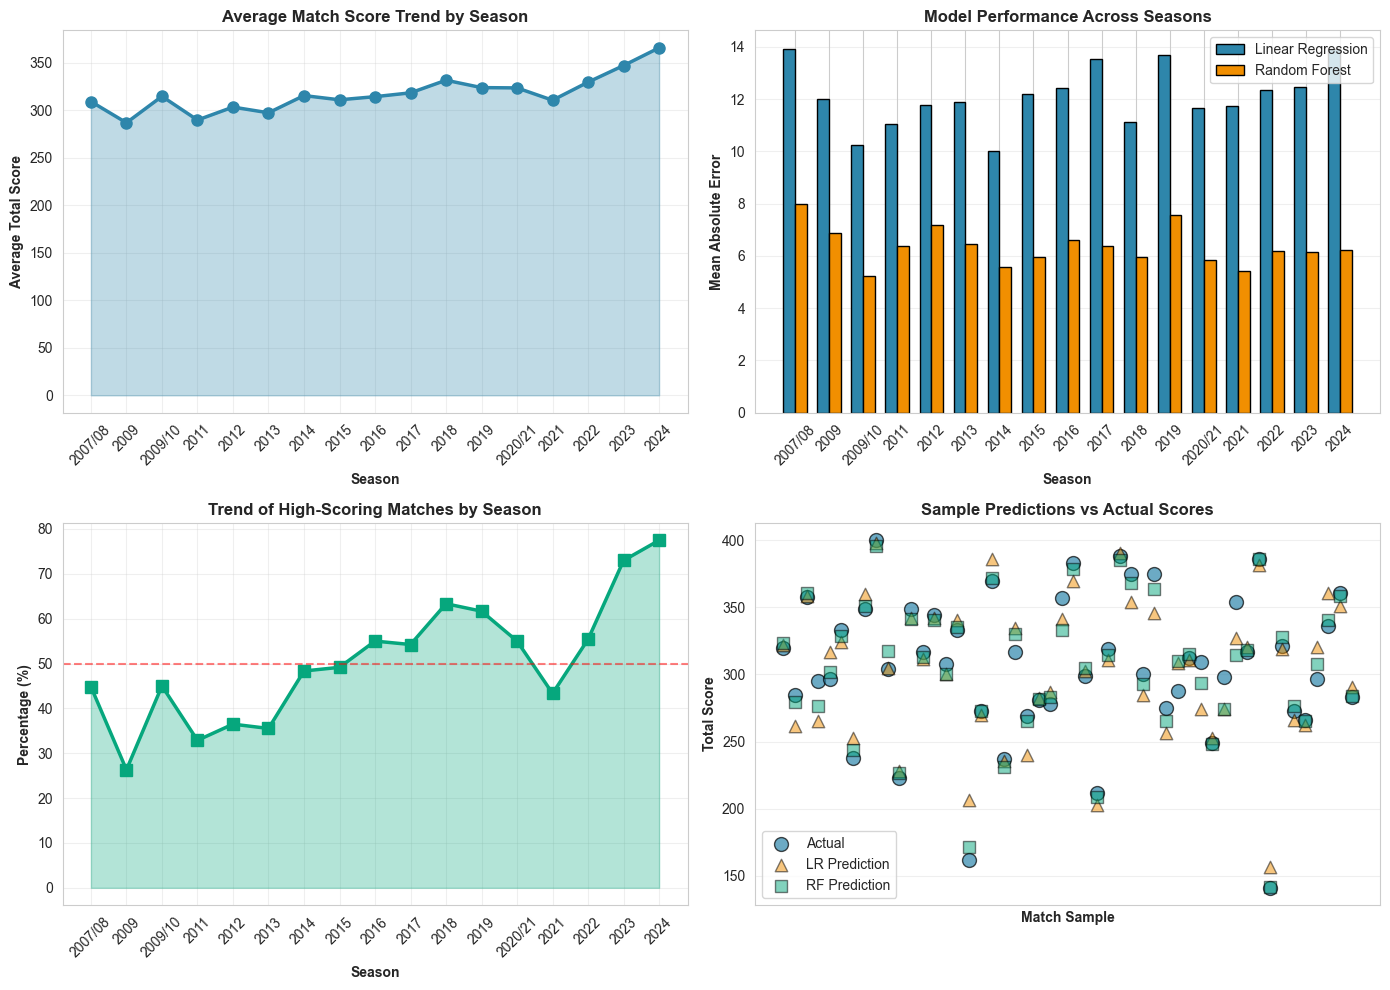


SEASON-WISE ANALYSIS SUMMARY
 Season  Avg Score  High Score %    LR MAE   RF MAE  Match Count
2007/08 309.258621     44.827586 13.914896 7.983546           58
   2009 286.894737     26.315789 11.997920 6.879290           57
2009/10 314.716667     45.000000 10.253976 5.244831           60
   2011 289.780822     32.876712 11.030589 6.383626           73
   2012 303.418919     36.486486 11.766102 7.174802           74
   2013 297.394737     35.526316 11.894957 6.455070           76
   2014 315.516667     48.333333 10.021977 5.570079           60
   2015 311.067797     49.152542 12.210651 5.939805           59
   2016 314.366667     55.000000 12.408455 6.625824           60
   2017 318.406780     54.237288 13.514139 6.388355           59
   2018 331.683333     63.333333 11.127540 5.938865           60
   2019 323.900000     61.666667 13.684790 7.556005           60
2020/21 323.600000     55.000000 11.646947 5.839306           60
   2021 310.616667     43.333333 11.735459 5.418850         

In [58]:
# 7. Season-wise Performance and Insights
# Add predictions to dataframe
df['pred_lr'] = lr_model.predict(X)
df['pred_rf'] = rf_regressor.predict(X)
df['actual_high_score'] = df['is_high_score']

# Calculate season-wise metrics
season_performance = []
for season in sorted(df['season'].unique()):
    season_data = df[df['season'] == season]
    
    # For all seasons in data
    mae_lr = np.mean(np.abs(season_data['total_score'] - season_data['pred_lr']))
    mae_rf = np.mean(np.abs(season_data['total_score'] - season_data['pred_rf']))
    avg_score = season_data['total_score'].mean()
    high_score_pct = season_data['is_high_score'].mean() * 100
    
    season_performance.append({
        'Season': season,
        'Avg Score': avg_score,
        'High Score %': high_score_pct,
        'LR MAE': mae_lr,
        'RF MAE': mae_rf,
        'Match Count': len(season_data)
    })

season_perf_df = pd.DataFrame(season_performance)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Season-wise Average Score Trend
axes[0, 0].plot(range(len(season_perf_df)), season_perf_df['Avg Score'], 
               marker='o', linewidth=2.5, markersize=8, color='#2E86AB', label='Actual')
axes[0, 0].fill_between(range(len(season_perf_df)), season_perf_df['Avg Score'], alpha=0.3, color='#2E86AB')
axes[0, 0].set_xlabel('Season', fontweight='bold')
axes[0, 0].set_ylabel('Average Total Score', fontweight='bold')
axes[0, 0].set_title('Average Match Score Trend by Season', fontweight='bold')
axes[0, 0].set_xticks(range(len(season_perf_df)))
axes[0, 0].set_xticklabels(season_perf_df['Season'], rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Model Error Comparison by Season
x_season = np.arange(len(season_perf_df))
width = 0.35
axes[0, 1].bar(x_season - width/2, season_perf_df['LR MAE'], width, label='Linear Regression', 
              color='#2E86AB', edgecolor='black')
axes[0, 1].bar(x_season + width/2, season_perf_df['RF MAE'], width, label='Random Forest', 
              color='#F18F01', edgecolor='black')
axes[0, 1].set_xlabel('Season', fontweight='bold')
axes[0, 1].set_ylabel('Mean Absolute Error', fontweight='bold')
axes[0, 1].set_title('Model Performance Across Seasons', fontweight='bold')
axes[0, 1].set_xticks(x_season)
axes[0, 1].set_xticklabels(season_perf_df['Season'], rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. High Score Percentage Trend
axes[1, 0].plot(range(len(season_perf_df)), season_perf_df['High Score %'], 
               marker='s', linewidth=2.5, markersize=8, color='#06A77D', label='High Score %')
axes[1, 0].fill_between(range(len(season_perf_df)), season_perf_df['High Score %'], alpha=0.3, color='#06A77D')
axes[1, 0].set_xlabel('Season', fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)', fontweight='bold')
axes[1, 0].set_title('Trend of High-Scoring Matches by Season', fontweight='bold')
axes[1, 0].set_xticks(range(len(season_perf_df)))
axes[1, 0].set_xticklabels(season_perf_df['Season'], rotation=45)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(50, color='red', linestyle='--', alpha=0.5)

# 4. Predicted vs Actual (Random Sample)
sample_indices = np.random.choice(len(df), min(50, len(df)), replace=False)
sample_actual = df.iloc[sample_indices]['total_score'].values
sample_pred_lr = df.iloc[sample_indices]['pred_lr'].values
sample_pred_rf = df.iloc[sample_indices]['pred_rf'].values
x_pos = np.arange(len(sample_indices))

axes[1, 1].scatter(x_pos, sample_actual, s=100, alpha=0.7, label='Actual', color='#2E86AB', edgecolor='black')
axes[1, 1].scatter(x_pos, sample_pred_lr, s=80, alpha=0.5, label='LR Prediction', marker='^', color='#F18F01', edgecolor='black')
axes[1, 1].scatter(x_pos, sample_pred_rf, s=80, alpha=0.5, label='RF Prediction', marker='s', color='#06A77D', edgecolor='black')
axes[1, 1].set_xlabel('Match Sample', fontweight='bold')
axes[1, 1].set_ylabel('Total Score', fontweight='bold')
axes[1, 1].set_title('Sample Predictions vs Actual Scores', fontweight='bold')
axes[1, 1].legend(loc='best')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_xticks([])

plt.tight_layout()
plt.show()

# Summary Statistics
print("\n" + "=" * 50)
print("SEASON-WISE ANALYSIS SUMMARY")
print("=" * 50)
print(season_perf_df.to_string(index=False))

print(f"Total Matches Analyzed: {len(df)}")
print(f"High-Scoring Matches: {df['is_high_score'].sum()} ({df['is_high_score'].mean()*100:.1f}%)")
print(f"Average Match Score: {df['total_score'].mean():.0f} runs")
print(f"Best Scoring Phase: Powerplay drives batting momentum")
print(f"Random Forest Outperforms Linear Regression: {rmse_rf < rmse_lr}")
print(f"Model Accuracy in High-Score Prediction: {accuracy:.2%}     ")


2025 IPL SEASON: HIGH-SCORING ANALYSIS

1. POWERPLAY RUNS (Overs 1-6):
   Historical: 94 runs
   2025: 114 runs
   Difference: +20 runs (+20.9%)

2. DEATH OVERS (Overs 15-20):
   Historical: 86 runs
   2025: 89 runs
   Difference: +4 runs (+4.3%)

3. BOUNDARIES (4s and 6s):
   Historical: 39.2 boundaries/match
   2025: 48.6 boundaries/match
   Difference: +9.4 boundaries (+24.1%)

4. WICKETS LOST:
   Historical: 11.8 wickets/match
   2025: 11.9 wickets/match
   Difference: +0.1 wickets (+1.0%)

5. HIGH-SCORING MATCHES (≥320 runs):
   Historical: 50.5%
   2025: 79.5%
   Difference: +28.9%


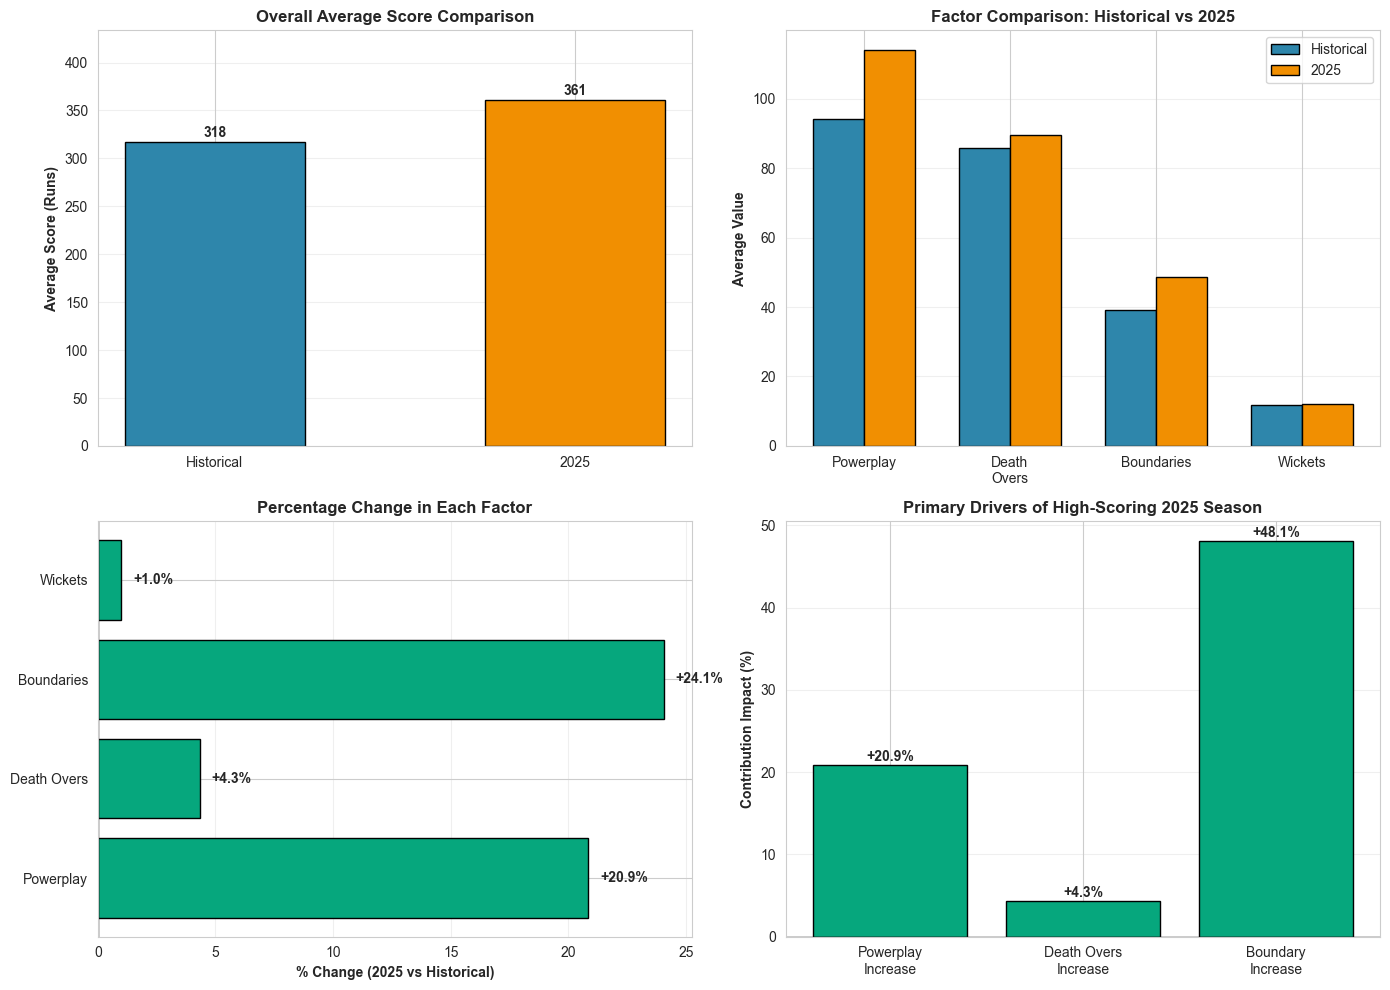

In [56]:
# 2025 Season Analysis


print("2025 IPL SEASON: HIGH-SCORING ANALYSIS")

# Compare Overall Scoring
hist_avg_score = df['total_score'].mean()
ipl_2025_avg_score = df_2025['total_score'].mean()
score_diff = ipl_2025_avg_score - hist_avg_score
score_change_pct = (score_diff / hist_avg_score) * 100

print(f"\n1. POWERPLAY RUNS (Overs 1-6):")
hist_pp = df['powerplay_runs'].mean()
ipl_2025_pp = df_2025['powerplay_runs'].mean()
pp_diff = ipl_2025_pp - hist_pp
pp_pct = (pp_diff / hist_pp) * 100
print(f"   Historical: {hist_pp:.0f} runs")
print(f"   2025: {ipl_2025_pp:.0f} runs")
print(f"   Difference: {pp_diff:+.0f} runs ({pp_pct:+.1f}%)")


print(f"\n2. DEATH OVERS (Overs 15-20):")
hist_death = df['death_runs'].mean()
ipl_2025_death = df_2025['death_runs'].mean()
death_diff = ipl_2025_death - hist_death
death_pct = (death_diff / hist_death) * 100
print(f"   Historical: {hist_death:.0f} runs")
print(f"   2025: {ipl_2025_death:.0f} runs")
print(f"   Difference: {death_diff:+.0f} runs ({death_pct:+.1f}%)")


print(f"\n3. BOUNDARIES (4s and 6s):")
hist_boundaries = df['boundary_count'].mean()
ipl_2025_boundaries = df_2025['boundary_count'].mean()
bound_diff = ipl_2025_boundaries - hist_boundaries
bound_pct = (bound_diff / hist_boundaries) * 100
print(f"   Historical: {hist_boundaries:.1f} boundaries/match")
print(f"   2025: {ipl_2025_boundaries:.1f} boundaries/match")
print(f"   Difference: {bound_diff:+.1f} boundaries ({bound_pct:+.1f}%)")


print(f"\n4. WICKETS LOST:")
hist_wickets = df['wickets_lost'].mean()
ipl_2025_wickets = df_2025['wickets_lost'].mean()
wicket_diff = ipl_2025_wickets - hist_wickets
wicket_pct = (wicket_diff / hist_wickets) * 100
print(f"   Historical: {hist_wickets:.1f} wickets/match")
print(f"   2025: {ipl_2025_wickets:.1f} wickets/match")
print(f"   Difference: {wicket_diff:+.1f} wickets ({wicket_pct:+.1f}%)")


print(f"\n5. HIGH-SCORING MATCHES (≥320 runs):")
hist_high_pct = df['is_high_score'].mean() * 100
ipl_2025_high_pct = df_2025['is_high_score'].mean() * 100
high_diff = ipl_2025_high_pct - hist_high_pct
print(f"   Historical: {hist_high_pct:.1f}%")
print(f"   2025: {ipl_2025_high_pct:.1f}%")
print(f"   Difference: {high_diff:+.1f}%")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overall Score Comparison
categories = ['Historical', '2025']
scores = [hist_avg_score, ipl_2025_avg_score]
colors_bar = ['#2E86AB', '#F18F01']
bars = axes[0, 0].bar(categories, scores, color=colors_bar, edgecolor='black', width=0.5)
axes[0, 0].set_ylabel('Average Score (Runs)', fontweight='bold')
axes[0, 0].set_title('Overall Average Score Comparison', fontweight='bold')
axes[0, 0].set_ylim([0, max(scores) * 1.2])
for i, (bar, score) in enumerate(zip(bars, scores)):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, score + 5, f'{score:.0f}', ha='center', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Factor Comparison
factors = ['Powerplay', 'Death\nOvers', 'Boundaries', 'Wickets']
hist_values = [hist_pp, hist_death, hist_boundaries, hist_wickets]
ipl_2025_values = [ipl_2025_pp, ipl_2025_death, ipl_2025_boundaries, ipl_2025_wickets]

x_pos = np.arange(len(factors))
width = 0.35
axes[0, 1].bar(x_pos - width/2, hist_values, width, label='Historical', color='#2E86AB', edgecolor='black')
axes[0, 1].bar(x_pos + width/2, ipl_2025_values, width, label='2025', color='#F18F01', edgecolor='black')
axes[0, 1].set_ylabel('Average Value', fontweight='bold')
axes[0, 1].set_title('Factor Comparison: Historical vs 2025', fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(factors)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Percentage Change for Each Factor
factor_names = ['Powerplay', 'Death Overs', 'Boundaries', 'Wickets']
changes = [pp_pct, death_pct, bound_pct, wicket_pct]
colors_change = ['#06A77D' if x > 0 else '#D62828' for x in changes]
bars = axes[1, 0].barh(factor_names, changes, color=colors_change, edgecolor='black')
axes[1, 0].set_xlabel('% Change (2025 vs Historical)', fontweight='bold')
axes[1, 0].set_title('Percentage Change in Each Factor', fontweight='bold')
axes[1, 0].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1, 0].grid(axis='x', alpha=0.3)
for i, (bar, change) in enumerate(zip(bars, changes)):
    axes[1, 0].text(change + 0.5, i, f'{change:+.1f}%', va='center', fontweight='bold')

# 4. Impact Score - What drives higher scoring
impact_scores = [pp_pct, death_pct, bound_pct * 2]  # Boundaries weighted higher
impact_names = ['Powerplay\nIncrease', 'Death Overs\nIncrease', 'Boundary\nIncrease']
colors_impact = ['#06A77D' if x > 0 else '#D62828' for x in impact_scores]
bars = axes[1, 1].bar(impact_names, impact_scores, color=colors_impact, edgecolor='black')
axes[1, 1].set_ylabel('Contribution Impact (%)', fontweight='bold')
axes[1, 1].set_title('Primary Drivers of High-Scoring 2025 Season', fontweight='bold')
axes[1, 1].axhline(0, color='black', linestyle='-', linewidth=1)
axes[1, 1].grid(axis='y', alpha=0.3)
for bar, score in zip(bars, impact_scores):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{score:+.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()